# Import modules


In [ ]:
import re
import time
from datetime import datetime
from urllib.parse import urljoin

from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.support.ui import WebDriverWait

# Setting up Selenium WebDriver


In [ ]:
url = "https://www.press.bmwgroup.com/global/article"

options = Options()
options.add_argument("--headless=new")  # No GUI

driver = webdriver.Chrome(options=options)  # let Selenium Manager resolve driver
driver.get(url)

In [ ]:
soup = BeautifulSoup(driver.page_source, "lxml")

# Analyzing the webpage structure and extracting article URLs


Each article is defined with $<article>$ tag.

The selector for each article is "article.newsfeed.clear-after.has-image.has-media".


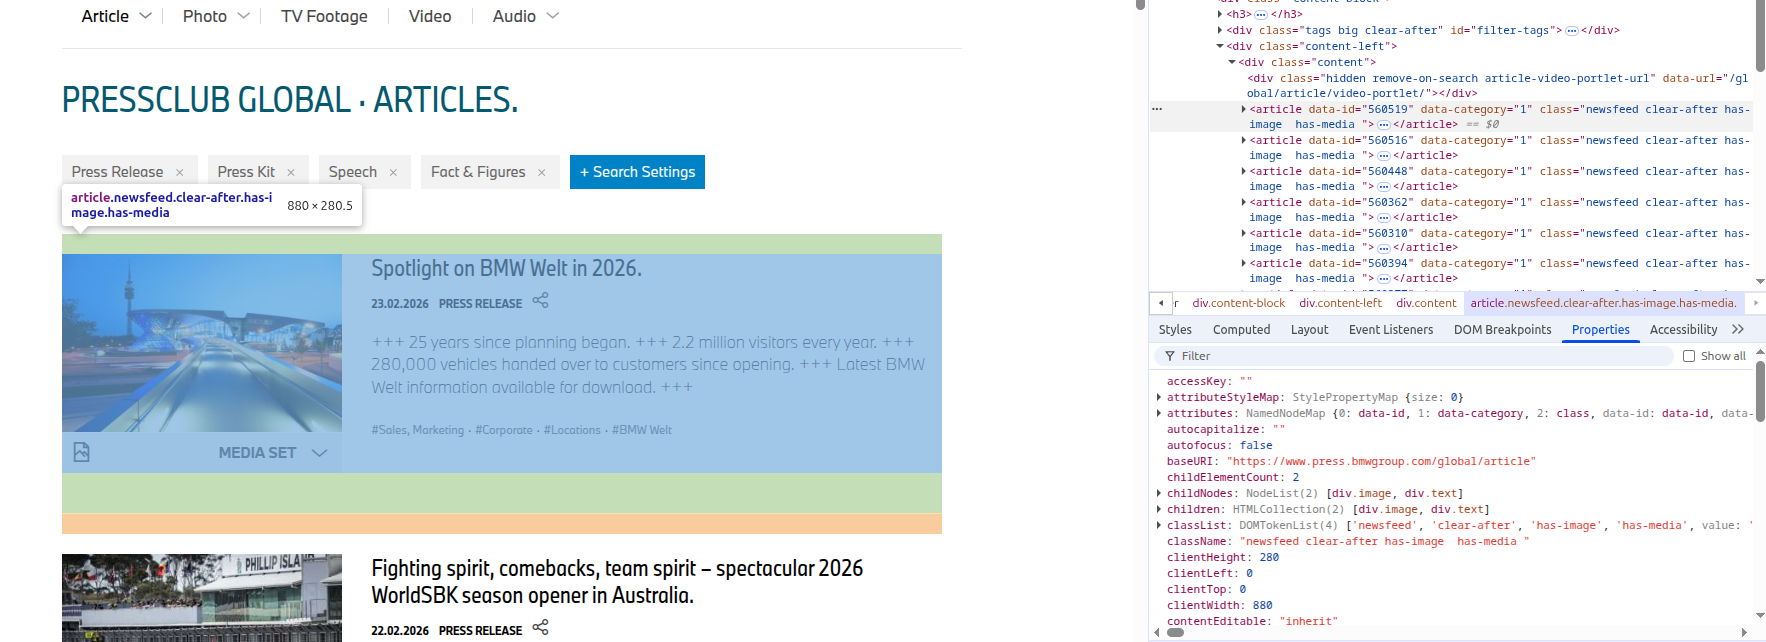


In [ ]:
article_ex = soup.select_one("article.newsfeed.clear-after.has-image.has-media")

In [ ]:
article_ex

<article class="newsfeed clear-after has-image has-media" data-category="1" data-id="560519"><div class="image"><div class="img thumb16-9" style="background-image:url('https://mediapool.bmwgroup.com/cache/P9/202409/P90570147/P90570147-highlights-at-the-end-of-the-year-at-bmw-welt-c-bmw-group-09-2024-329px.jpg');"> </div><div class="buttons"><a class="bmw-ci-document-img-med" href="/global/article/detail/T0455753EN/spotlight-on-bmw-welt-in-2026?showMedia=photo" title="Contains photos"> </a><div class="clickable download"><span class="text">Media Set</span><i class="down bmw-ci-down-nav-med"> </i><i class="up bmw-ci-up-nav-med"> </i></div></div><div class="download-dropdown"><a class="clickable download" href="/global/oneclick/download/T0455753EN/attachment" rel="nofollow"><i class="icon ready bmw-ci-download-sm"> </i><i class="icon not-ready bmw-ci-repeat-sm"> </i>
<div class="loading ispinner gray animating">
<div class="ispinner-blade"></div>
<div class="ispinner-blade"></div>
<div cl

href to the article is located in "div.text h3 a" tag.

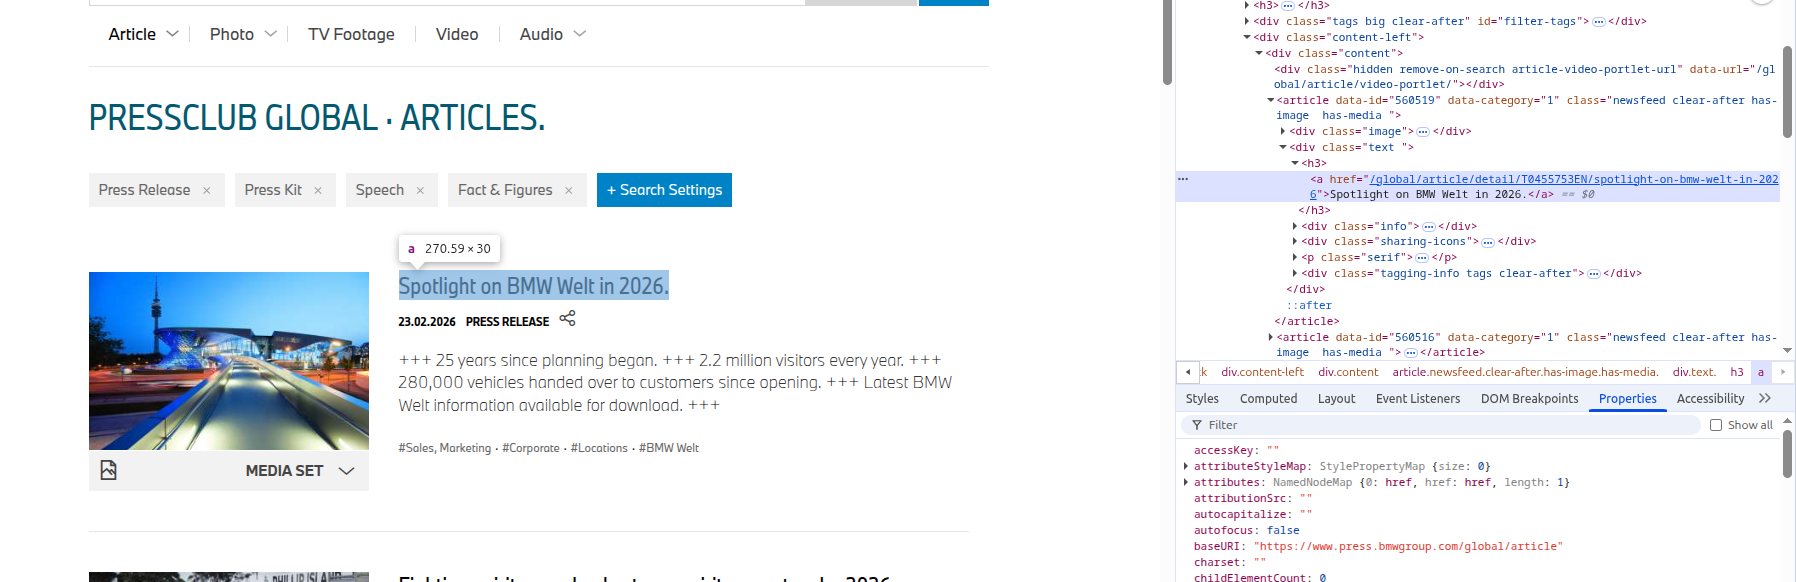


In [ ]:
link_tag = article_ex.select_one("div.text h3 a[href]")
article_url = urljoin(url, link_tag["href"])

driver.get(article_url)
print(driver.current_url)
print(driver.title)

https://www.press.bmwgroup.com/global/article/detail/T0455753EN/spotlight-on-bmw-welt-in-2026
Spotlight on BMW Welt in 2026.


## Loop over articles and extract URLs and titles


In [ ]:
for article in soup.find_all("article", class_="newsfeed clear-after has-image has-media"):
    link_tag = article.select_one("div.text h3 a[href]")
    if link_tag:
        article_url = urljoin(url, link_tag["href"])
        article_title = link_tag.get_text(strip=True)
        print(f"Title: {article_title}")
        print(f"URL: {article_url}")
        print("-" * 40)

Title: Spotlight on BMW Welt in 2026.
URL: https://www.press.bmwgroup.com/global/article/detail/T0455753EN/spotlight-on-bmw-welt-in-2026
----------------------------------------
Title: Fighting spirit, comebacks, team spirit – spectacular 2026 WorldSBK season opener in Australia.
URL: https://www.press.bmwgroup.com/global/article/detail/T0455749EN/fighting-spirit-comebacks-team-spirit-–-spectacular-2026-worldsbk-season-opener-in-australia
----------------------------------------
Title: 2026 BMW Motorrad Motorsport Guide.
URL: https://www.press.bmwgroup.com/global/article/detail/T0455710EN/2026-bmw-motorrad-motorsport-guide
----------------------------------------
Title: MINI Aceman SE: An electrifying companion for urban life in Tokyo.
URL: https://www.press.bmwgroup.com/global/article/detail/T0455629EN/mini-aceman-se:-an-electrifying-companion-for-urban-life-in-tokyo
----------------------------------------
Title: Initial information on the Concorso d’Eleganza Villa d’Este 2026. Media

### expand show more button and extract more articles

It seems, you need to click "show more" button once to load more articles, and then scroll down to load all articles.


In [ ]:
from selenium.common.exceptions import TimeoutException

# Move back to article listing page
driver.get(url)
wait = WebDriverWait(driver, 10)

show_more_btn = driver.find_element(By.CSS_SELECTOR, "button#lazy-load-button.remove-on-search.clear")

driver.execute_script("arguments[0].scrollIntoView({block: 'center'});", show_more_btn)
driver.execute_script("arguments[0].click();", show_more_btn)
time.sleep(1)  # wait for new articles to load

# Final scroll to ensure lazy content is rendered
for _ in range(10):
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(1)

# Parse all loaded articles
soup = BeautifulSoup(driver.page_source, "lxml")
article_items = []
for article in soup.select("article.newsfeed"):
    data_id = article.get("data-id")

    link_tag = article.select_one("div.text h3 a[href]")
    if not link_tag:
        continue
    article_items.append(
        {
            "title": link_tag.get_text(strip=True),
            "data_id": data_id,
            "url": urljoin(url, link_tag["href"]),
        }
    )

print(f"Total loaded articles: {len(article_items)}")
article_items[:5]

Total loaded articles: 200


[{'title': 'Spotlight on BMW Welt in 2026.',
  'data_id': '560519',
  'url': 'https://www.press.bmwgroup.com/global/article/detail/T0455753EN/spotlight-on-bmw-welt-in-2026'},
 {'title': 'Fighting spirit, comebacks, team spirit – spectacular 2026 WorldSBK season opener in Australia.',
  'data_id': '560516',
  'url': 'https://www.press.bmwgroup.com/global/article/detail/T0455749EN/fighting-spirit-comebacks-team-spirit-–-spectacular-2026-worldsbk-season-opener-in-australia'},
 {'title': '2026 BMW Motorrad Motorsport Guide.',
  'data_id': '560448',
  'url': 'https://www.press.bmwgroup.com/global/article/detail/T0455710EN/2026-bmw-motorrad-motorsport-guide'},
 {'title': 'MINI Aceman SE: An electrifying companion for urban life in Tokyo.',
  'data_id': '560362',
  'url': 'https://www.press.bmwgroup.com/global/article/detail/T0455629EN/mini-aceman-se:-an-electrifying-companion-for-urban-life-in-tokyo'},
 {'title': 'Initial information on the Concorso d’Eleganza Villa d’Este 2026. Media accred

### Open one article and extract content


In [ ]:
import json

article_ex = article_items[0]
print(json.dumps(article_ex, indent=2))

{
  "title": "Spotlight on BMW Welt in 2026.",
  "data_id": "560519",
  "url": "https://www.press.bmwgroup.com/global/article/detail/T0455753EN/spotlight-on-bmw-welt-in-2026"
}


In [ ]:
article_page = driver.get(article_ex["url"])
wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "body")))  # wait for page to load

article_soup = BeautifulSoup(driver.page_source, "lxml")

In each article, the contents are labeled with following tags:

- title: class article-detail remove-on-search => h1
- date: class article-info -> date
- data_id: data-id
- category: class article-info -> category
- teaser: class teaser clear (not all articles have this)
- body: #article-text

Some article have "#content > div > div.content-left > div > div.right > button" to show more.
<button type="button" class="readmore">
<span>Show entire text</span>
<i class="bmw-ci-expand-sm"></i>
</button>


Weirdly, the paragraphs in the body text are separated by $nbsp; even for some single sentences. Therefore, do not separate paragraphs by $\\n$ but keep them as a whole.
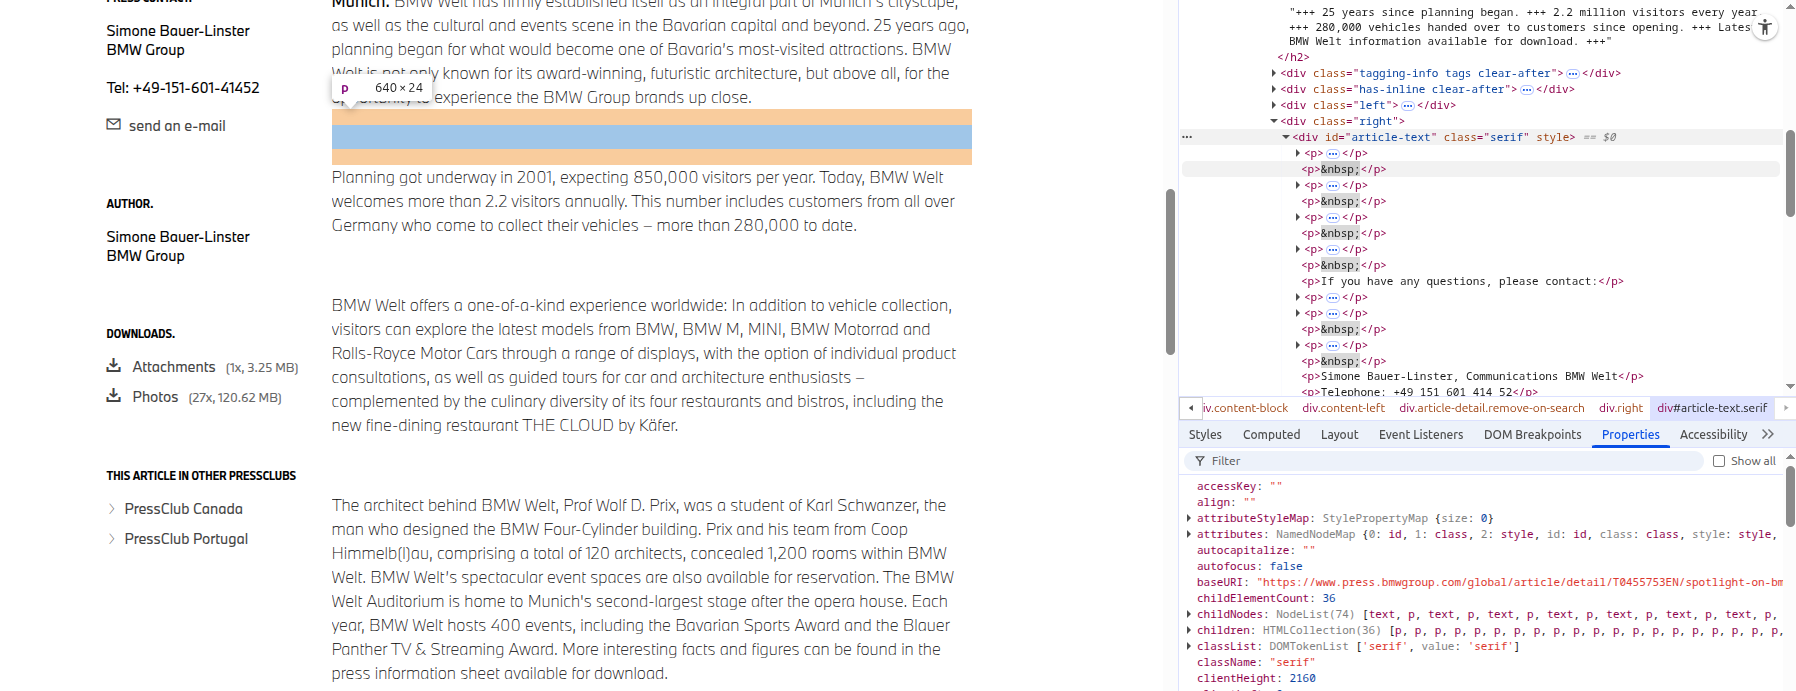


In [ ]:
from selenium.common.exceptions import TimeoutException


def extract_detail(article):
    detail_url = article["url"]
    driver.get(detail_url)
    wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "body")))

    # Expand full body if article has "Show entire text"
    try:
        readmore_btn = WebDriverWait(driver, 3).until(EC.element_to_be_clickable((By.CSS_SELECTOR, "button.readmore")))
        driver.execute_script("arguments[0].scrollIntoView({block:'center'});", readmore_btn)
        driver.execute_script("arguments[0].click();", readmore_btn)
        time.sleep(0.8)
    except TimeoutException:
        pass

    soup = BeautifulSoup(driver.page_source, "lxml")

    title_node = soup.select_one("div.article-detail.remove-on-search h1, h1")
    title = title_node.get_text(strip=True) if title_node else None

    date_node = soup.select_one(".article-info .date, .article-info time, time")
    date_raw = date_node.get_text(" ", strip=True) if date_node else None

    category_node = soup.select_one(".article-info .category")
    category = category_node.get_text(" ", strip=True) if category_node else None

    teaser_node = soup.select_one(".teaser.clear, .teaser")
    teaser = teaser_node.get_text(" ", strip=True) if teaser_node else None

    body_container = soup.select_one("#article-text")
    body_text = None
    if body_container:
        paragraphs = body_container.select("p")
        if paragraphs:
            body_text = [p.get_text(" ", strip=True) for p in paragraphs if p.get_text(strip=True)]
        else:
            body_text = body_container.get_text("\n", strip=True)

    article["date_raw"] = date_raw
    article["category"] = category
    article["teaser"] = teaser
    article["text"] = body_text
    return article


# Run on first N links from article_items (change N as needed)
N = 5
detailed_article = [extract_detail(article) for article in article_items[:N]]

print(f"Extracted detail pages: {len(detailed_article)}")
detailed_article[0] if detailed_article else None

Extracted detail pages: 5


{'title': 'Spotlight on BMW Welt in 2026.',
 'data_id': '560519',
 'url': 'https://www.press.bmwgroup.com/global/article/detail/T0455753EN/spotlight-on-bmw-welt-in-2026',
 'date_raw': '23.02.2026',
 'category': 'Press Release',
 'teaser': '+++ 25 years since planning began. +++ 2.2 million visitors every year. +++ 280,000 vehicles handed over to customers since opening. +++ Latest BMW Welt information available for download. +++',
 'text': ['Munich. BMW Welt has firmly established itself as an\n  integral part of Munich’s cityscape, as well as the cultural and\n  events scene in the Bavarian capital and beyond. 25 years ago,\n  planning began for what would become one of Bavaria’s most-visited\n  attractions. BMW Welt is not only known for its award-winning,\n  futuristic architecture, but above all, for the opportunity to\n  experience the BMW Group brands up close.',
  'Planning got underway in 2001, expecting 850,000 visitors per year.\n  Today, BMW Welt welcomes more than 2.2 visit

The body text requires some cleaning.

Remove text elements if ...

1. URLs: http:, https:, www.<?>.<?> (mostly links to other articles)
2. email: <?>@<?>.<?> => regular expression: \b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b
3. contain telephone numbers: +dd, +ddd
4. replace all \n, \r, \t, double-space with space and remove extra spaces => regular expression: \s+ -> " "

Replace +++ with "" in teaser text


In [ ]:
# Clean text
def clean_text(text):
    # remove elements first then merge paragraphs

    # remove URLs
    text = [i for i in text if not re.search(r"http[s]?://|www\.\S+", i)]

    # remove emails
    text = [i for i in text if not re.search(r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b", i)]

    # remove phone numbers
    text = [i for i in text if not re.search(r"\+\d{1,3}", i)]

    # remove special characters (except basic punctuation)
    text = [i.replace("\n", "").replace("\r", "").replace("  ", " ").strip() for i in text]

    # merge paragraphs
    text = " ".join(i for i in text)

    return text


def clean_teaser(teaser):
    if teaser:
        teaser = teaser.replace("+++", "").replace("  ", " ").strip()

    return teaser.strip() if teaser else teaser


for content in detailed_article:
    if content["text"]:
        content["text"] = clean_text(content["text"])

    if content["teaser"]:
        content["teaser"] = clean_teaser(content["teaser"])

print(json.dumps(detailed_article[0], indent=2, ensure_ascii=False) if detailed_article else "No content extracted")

{
  "title": "Spotlight on BMW Welt in 2026.",
  "data_id": "560519",
  "url": "https://www.press.bmwgroup.com/global/article/detail/T0455753EN/spotlight-on-bmw-welt-in-2026",
  "date_raw": "23.02.2026",
  "category": "Press Release",
  "teaser": "25 years since planning began. 2.2 million visitors every year. 280,000 vehicles handed over to customers since opening. Latest BMW Welt information available for download.",
  "text": "Munich. BMW Welt has firmly established itself as an integral part of Munich’s cityscape, as well as the cultural and events scene in the Bavarian capital and beyond. 25 years ago, planning began for what would become one of Bavaria’s most-visited attractions. BMW Welt is not only known for its award-winning, futuristic architecture, but above all, for the opportunity to experience the BMW Group brands up close. Planning got underway in 2001, expecting 850,000 visitors per year. Today, BMW Welt welcomes more than 2.2 visitors annually. This number includes cus

Process date_raw using datetime


In [15]:
from datetime import datetime


def convert_datetime(date_str: str, fmt: str = "dd.mm.yyyy") -> datetime:
    if fmt == "dd.mm.yyyy":
        return datetime.strptime(date_str, "%d.%m.%Y")
    else:
        raise ValueError(f"Unsupported format: {fmt}")


dt = convert_datetime("23.02.2026")

In [ ]:
dt.strftime("%Y-%m-%d")

'2026-02-23'

In [ ]:
dt.strftime("%Y%m%d")

'20260223'

Decided to format data_raw as yyyymmdd.
